In [17]:
import sys
from os import path, getcwd
import pathlib
import itertools
from sklearn.metrics import average_precision_score, roc_auc_score
from pprint import pprint

# where everything is stored (data and code)
ROOT = pathlib.Path(getcwd()).parent.absolute()
# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

# data paths
DATA_DIR = path.join(ROOT, 'data/')
# checkpoints of preprocessed data
CHECKPOINTS = {'iwae': path.join(DATA_DIR, 'checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.17_13-26-03_normal_new/'),
           'iwae_no_bias': path.join(DATA_DIR, 'checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.17_12-22-18_no_bias_new/'),
           'nf': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0_new/06.17_09-57-55_normal/'),
           'nf_new_loss': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0_new/06.17_12-28-10_new_loss/'),
           'nf_no_bias': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0_new/06.18_07-55-21_no_bias/'),
           'survae': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.18_07-53-58_normal_new/'),
           'survae_new_loss': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.22_12-40-55_new_loss/'),
           'survae_hierarchy': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-4_scales-5_pool-max_mnist_cls-0_new/06.17_12-42-56_hierarchy/'),
           }

%reload_ext autoreload
%autoreload 2

# Plotting Functions
from plotting import *
from misc.common_functions import *
from precomputation.initialization import load_data, load_preprocessings
from precomputation.pre_sampling import SampleType

_=%matplotlib inline

for name, path in CHECKPOINTS.items():
    print(f'{model_short_to_name(name)} :\t{path}')
    

Importance Weighted VAE :	C:\Mega\trunk\master-thesis\data/checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.17_13-26-03_normal_new/
Importance Weighted VAE - no bias :	C:\Mega\trunk\master-thesis\data/checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.17_12-22-18_no_bias_new/
Normalizing Flow :	C:\Mega\trunk\master-thesis\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0_new/06.17_09-57-55_normal/
Normalizing Flow - new loss :	C:\Mega\trunk\master-thesis\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0_new/06.17_12-28-10_new_loss/
Normalizing Flow - no bias :	C:\Mega\trunk\master-thesis\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0_new/06.18_07-55-21_no_bias/
SurVAE :	C:\Mega\trunk\master-thesis\data/checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.18_07-53-58_normal_new/
SurVAE - new loss :	C:\Mega\trunk\master-thesis\data/checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.22_12-40-55_new_loss/
survae_hierarchy :	C:\Mega\trunk\master-thesis\data/checkpo

In [2]:
# config
configs, MAIN_TEST_CLS = load_configs(CHECKPOINTS, DATA_DIR, verbose=1)
for _, args in configs.items():
    args.new_use_case = True
    
# Data
all_loaders = load_data(configs, verbose=False)

# Precomputed information
all_models, samples, artificial_images, additionals = load_preprocessings(CHECKPOINTS)

# Quantile where we denote outliers
QUANTILE = 0.01

-------------------------------------------------------------
Importance Weighted VAE
wandb_name_ext: normal
debug: False
-------------------------------------------------------------
Importance Weighted VAE
wandb_name_ext: no_bias
debug: False
-------------------------------------------------------------
Normalizing Flow
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: new_loss
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: no_bias
debug: False
-------------------------------------------------------------
SurVAE
wandb_name_ext: normal
debug: False
-------------------------------------------------------------
SurVAE
wandb_name_ext: new_loss
debug: False
-------------------------------------------------------------
SurVAE
wandb_name_ext: hierarchy
debug: False


In [3]:
for models, config in configs.items():
    if 'new_loss' in dir(config) and config.new_loss is True:
        print(f'Avg log volume: {model_short_to_name(models)} {additionals[models]["avg_log_volume"]}')

Avg log volume: Normalizing Flow - new loss 406.5948486328125
Avg log volume: SurVAE - new loss -193.70957946777344


### Sanity Check

In [4]:
for m_1 in all_models:
    for m_2 in all_models:
        # (I know, I compute twice as much as needed)
        if m_1 == m_2:
            continue
        for cls in all_models[m_1]:
            imgs_1 = all_models[m_1][cls][IMG_IDX]
            imgs_2 = all_models[m_2][cls][IMG_IDX]
            a = all_models[m_1][cls][IMG_IDX] - all_models[m_2][cls][IMG_IDX]
            np.testing.assert_array_equal(all_models[m_1][cls][IMG_IDX], all_models[m_2][cls][IMG_IDX], f'{m_1} or in {m_2}')

In [5]:
iwae_losses = {name: losses for name, losses in all_models.items() if name.startswith('iwae')}
no_iwae_losses = {name: losses for name, losses in all_models.items() if name not in iwae_losses}

In [6]:
#_=show_outlier_loss_histogram(no_iwae_losses, lim_left=-1.75, lim_right=-0.25, quantile=QUANTILE)

In [7]:
#_=show_outlier_loss_histogram(iwae_losses, lim_left=-25, lim_right=-7.5)

# Studentized Version of all Models

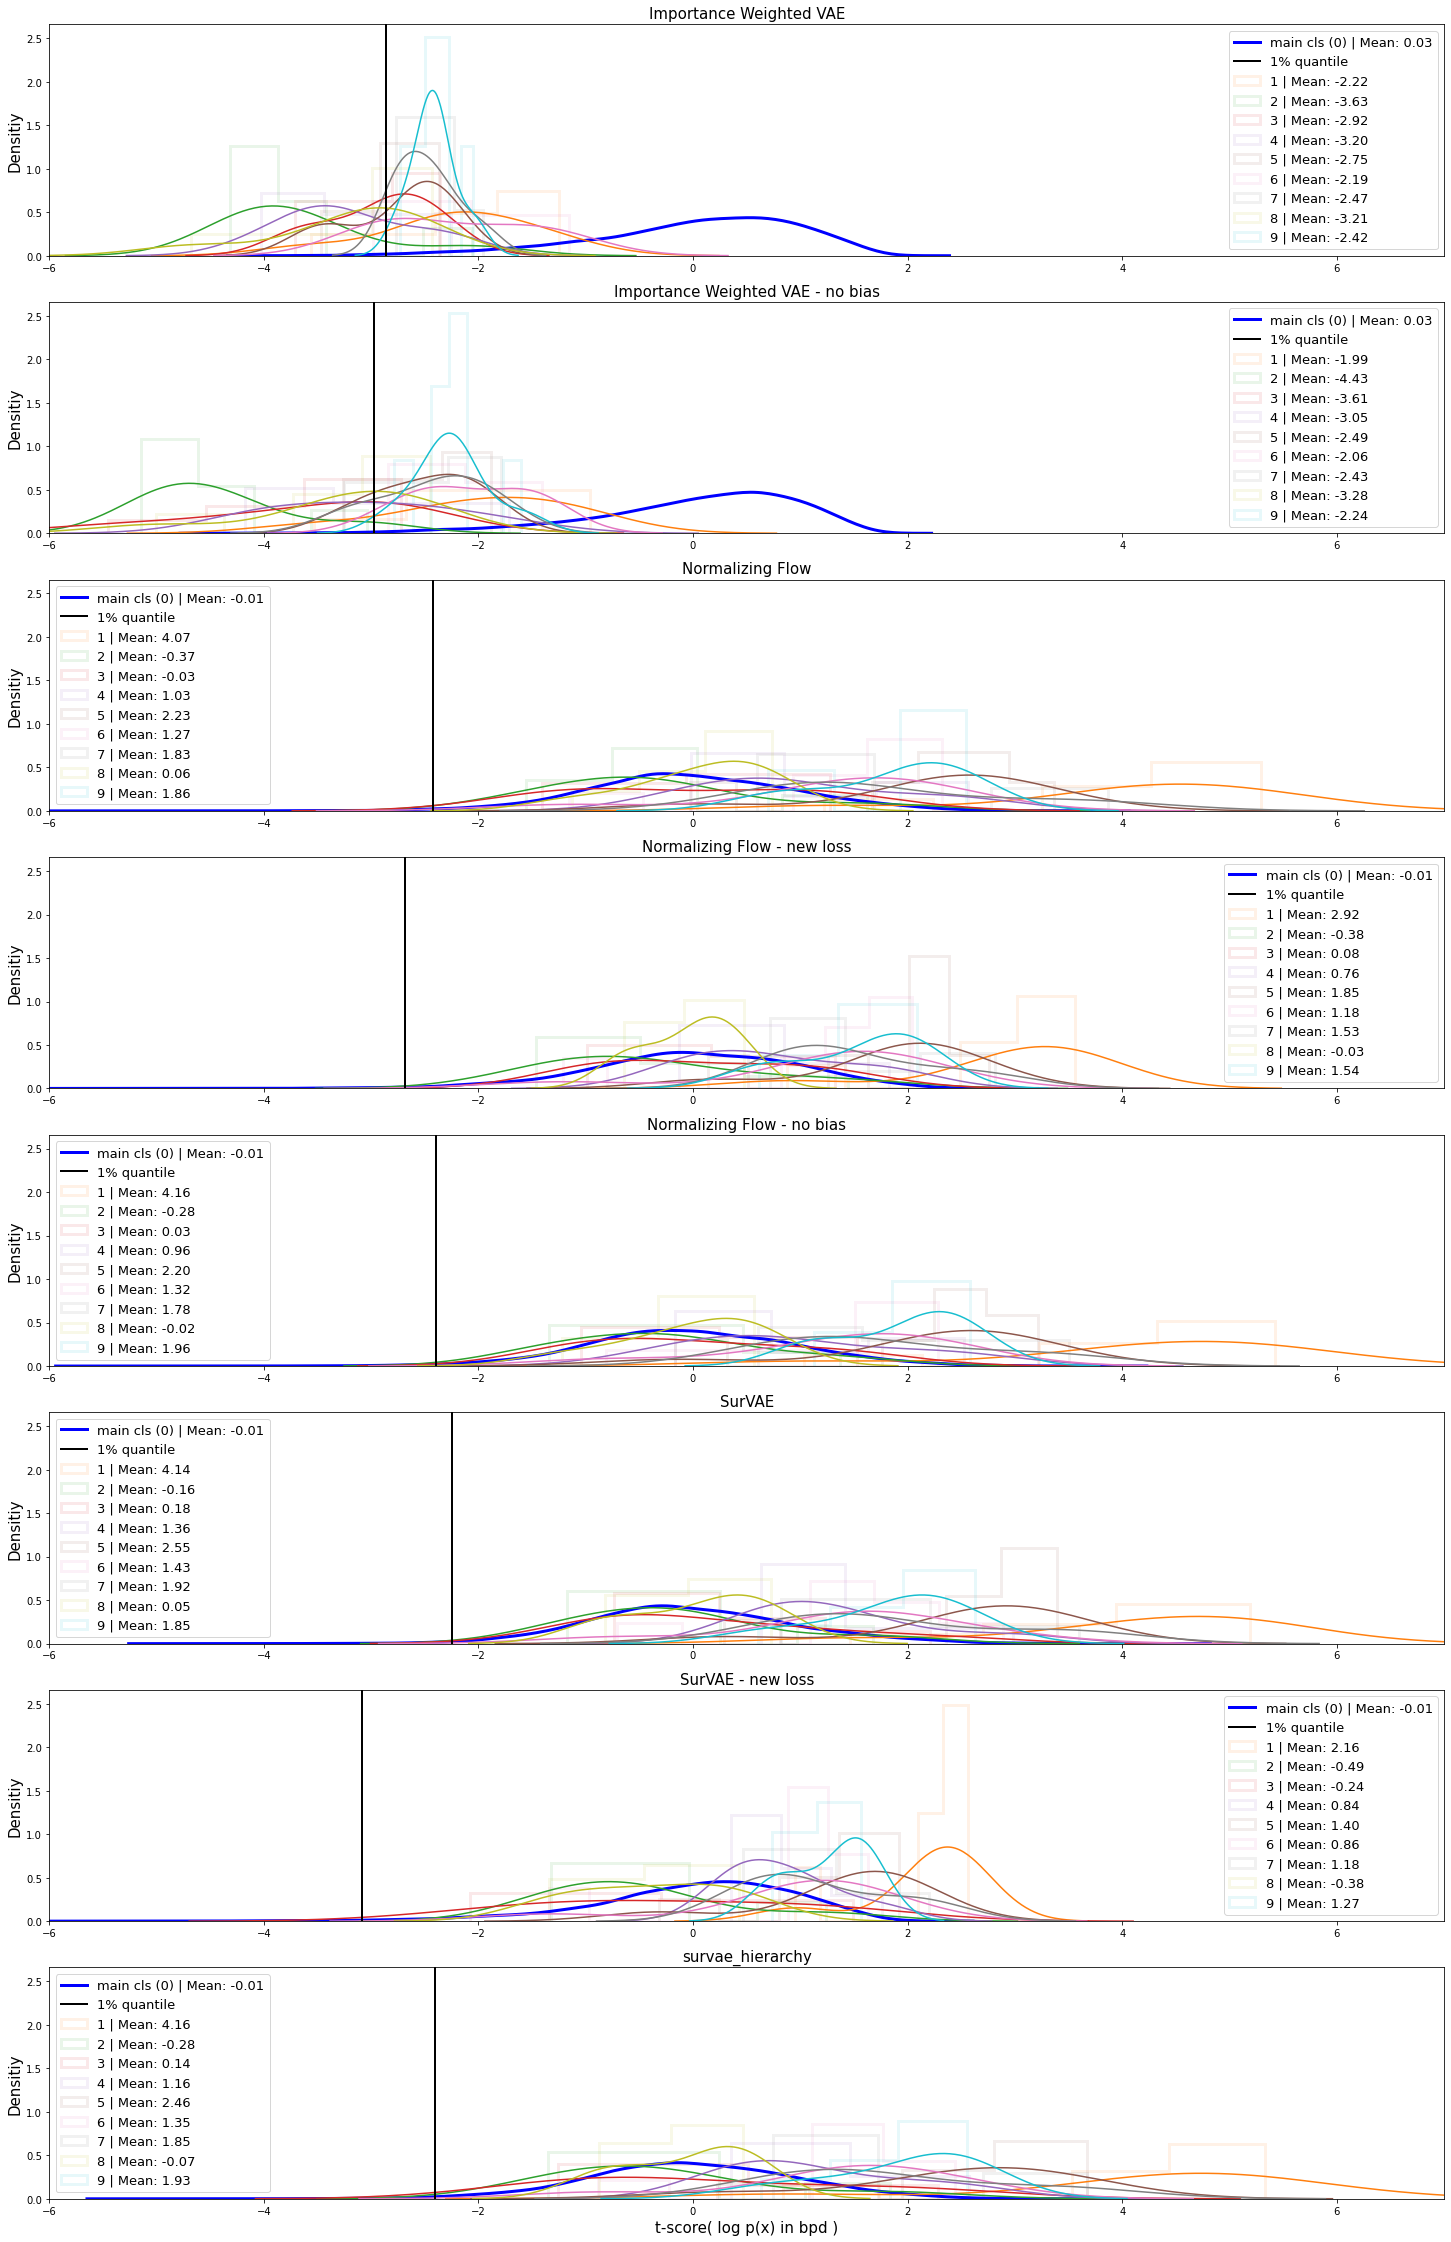

In [8]:
_=show_outlier_loss_histogram(all_models, score_idx=T_SCORE, lim_left=-6, lim_right=7)

$\newcommand{\Dt}{D_0^t}$
$\newcommand{\Ce}{\mathfrak{C}}$

Definition of outlier score:<br>
Let 
Let $\Ce$ be the set of samples from outliers and $\Dt$ be the training set.<br>
$\Ce := \{D_c | c \neq 0\}$

For a given model $f$ that returns the log likelihood in bits per dim (i.e. $f(x) = \frac{p_X(x)}{\log(2) \cdot \dim(x)}$) <br>
$f'$ is the studentized version of $f$:<br>
$f'(x) = \frac{f(x) - \text{mean}(f)}{\text{var}(f)}$<br>
Mean and variance are calculated over $\Dt$.<br>
We refer to the score of $f'$ as t-score.<br><br>

$q_i$ is the $i$th quantile of the inliers:<br>
$q_i := \text{sort}(f'(D_0^t))[i \cdot |\Dt|]$<br>
That is, we apply $f'$ to all element in $\Dt$, sort these score and use that t-score such that $(1-i) \cdot 100$ percent of all samples in $\Dt$ obtain a higher t-score than $q_i$.<br><br>

Than we define the expert score $\Psi$:<br>
$\Psi_i(f) := \frac{1}{|\Ce|} \sum_{C \in \Ce} \left( \frac{1}{|C|} \sum_{c \in C} \mathbb{1}_{\{f'(c) > q_i\}} \right)$<br>
Which is: the average amount of samples of outliers averaged over all outlier classes, that obtain a higher t-score than $q_i$.<br>
We will use $\Psi_{0.01}$

In [9]:
def combine_models_to_expert(used_model):
    
    expert_model = dict()
    for cls in all_models['nf']:    
        new_latent_info = dict()
        new_latent_info[IMG_IDX] = all_models['nf'][cls][IMG_IDX]
        
        score = None
        # in this loop we create the histogram for a potential best expert gate
        for model in used_model:
            #### besser zusammenfassen
            score_of_current_model = all_models[model][cls][T_SCORE]    
            # no initial score to compare with was set
            # thus we just take the values of the first model
            if score is None:
                score = score_of_current_model
            else:
                if cls == MAIN_TEST_CLS:
                    score = np.maximum(score, score_of_current_model)
                else:
                    score = np.minimum(score, score_of_current_model)

        new_latent_info[T_SCORE] = score
        expert_model[cls] = new_latent_info
    
    # create training class (consists of all classes)
    all_t_scores = [expert_model[cls][T_SCORE] for cls in expert_model]
    expert_model[MAIN_TRAIN_CLS][T_SCORE] = np.concatenate(all_t_scores)
            
    return expert_model

def compute_quantile_remove(expert, q=0.01):
    scores = [expert[cls][T_SCORE] for cls in expert]
    scores = np.concatenate(scores)
    sorted_scores = np.sort(scores)
    q = sorted_scores[round(q * len(sorted_scores))]
    return q

def psi_score(expert, q):
    """expert: given expert
    q: actual quantile (location of that quantile)"""
    
    psi_per_class = []
    main_cls_score = None
    for cls in expert:
        if cls == MAIN_TRAIN_CLS:
            continue
            
        scores = expert[cls][T_SCORE]
        if cls == MAIN_TEST_CLS:
            main_cls_score = (scores > q).mean()
        else:
            psi_per_class.append((scores > q).mean())
            
    TPR = main_cls_score
    FNR = 1 - TPR
    FPR = np.mean(psi_per_class)
    TNR = 1 - FPR
    
    return TPR + TNR - 1, (TPR, TNR)

    # likelihood ratio for positive results
    #return main_cls_score / np.mean(psi_per_class)
    #compute true positive rate | sensitivity
    #return main_cls_score / (main_cls_score + np.mean(psi_per_class))
    #return main_cls_score / (main_cls_score + np.sum(psi_per_class))


def avg_precision(expert, dummy=None):
    true_class = []
    all_scores = []
    
    for cls in expert:
        if cls == MAIN_TRAIN_CLS:
            continue
            
        scores = expert[cls][T_SCORE]
        all_scores.append(-scores)
        if cls == MAIN_TEST_CLS:
            true_class.append(np.zeros_like(scores))
        else:
            true_class.append(np.ones_like(scores))
    
    all_scores = np.concatenate(all_scores)
    true_class = np.concatenate(true_class)
    
    ap = average_precision_score(true_class, all_scores)
    auroc = roc_auc_score(true_class, all_scores)
    
    return ap, auroc

expert_model = combine_models_to_expert(all_models.keys())
avg_precision(expert_model)
#quantile = compute_quantile_of_main_cls(expert_model, q=QUANTILE)

(0.9113596778037232, 0.9989514565785753)

In [10]:
#all_experts = create_theoretical_experts(all_models, combine_models_to_expert, compute_quantile, psi_score)
all_experts = create_theoretical_experts(all_models, combine_models_to_expert, compute_quantile, avg_precision)
expert_scores = remove_experts_without_effect(all_experts, round_digits=2)
#print('Informedness, (TPR, TNR)')

In [11]:
for model, score in expert_scores:
    if len(model) == 1:
        #print(f'{model_short_to_name(model[0])} : {score}')
        #print(f'{model_short_to_name(model[0])}:\t i:{score[0]:.3f} TPR: {score[1][0]:.3f} TNR: {score[1][1]:.3f}')
        print(f'{model_short_to_name(model[0])}:\t ap:{score[0]:.5f} auroc: {score[1]:.3f}')

Importance Weighted VAE:	 ap:0.41321 auroc: 0.982
Importance Weighted VAE - no bias:	 ap:0.35746 auroc: 0.976
SurVAE - new loss:	 ap:0.00644 auroc: 0.300
Normalizing Flow:	 ap:0.00577 auroc: 0.250
Normalizing Flow - new loss:	 ap:0.00575 auroc: 0.264
survae_hierarchy:	 ap:0.00566 auroc: 0.245
Normalizing Flow - no bias:	 ap:0.00565 auroc: 0.250
SurVAE:	 ap:0.00540 auroc: 0.222


In [18]:
pprint(expert_scores)

[(('iwae',
   'iwae_no_bias',
   'nf',
   'nf_new_loss',
   'nf_no_bias',
   'survae',
   'survae_new_loss',
   'survae_hierarchy'),
  (0.9113596778037232, 0.9989514565785753)),
 (('iwae',
   'iwae_no_bias',
   'nf_new_loss',
   'survae',
   'survae_new_loss',
   'survae_hierarchy'),
  (0.9045795654554912, 0.9988525807734847)),
 (('iwae', 'iwae_no_bias', 'nf', 'nf_new_loss', 'survae_new_loss'),
  (0.8942595757211493, 0.9986341342273545)),
 (('iwae', 'iwae_no_bias', 'nf_no_bias', 'survae_new_loss'),
  (0.8808783425975935, 0.9984225859932074)),
 (('iwae', 'nf', 'nf_new_loss', 'nf_no_bias', 'survae', 'survae_hierarchy'),
  (0.8748390135067092, 0.9985329589849363)),
 (('iwae', 'nf_new_loss', 'survae'), (0.8642510613292914, 0.9983214107507894)),
 (('iwae', 'iwae_no_bias', 'survae_hierarchy'),
  (0.8545067587260885, 0.9979535007783594)),
 (('iwae_no_bias',
   'nf',
   'nf_new_loss',
   'nf_no_bias',
   'survae',
   'survae_new_loss',
   'survae_hierarchy'),
  (0.8449775526809897, 0.997774144

In [13]:
from collections import OrderedDict
expert_mixtures = OrderedDict()
max_mixtures = 3
for experts, _ in expert_scores:
    if len(experts) == 1:
        #continue
        model_name = experts[0]
        expert_mixtures[model_name] = all_models[model_name]
    #else:
    elif max_mixtures > 0:
        expert_mixtures[experts] = combine_models_to_expert(experts)
        max_mixtures -= 1

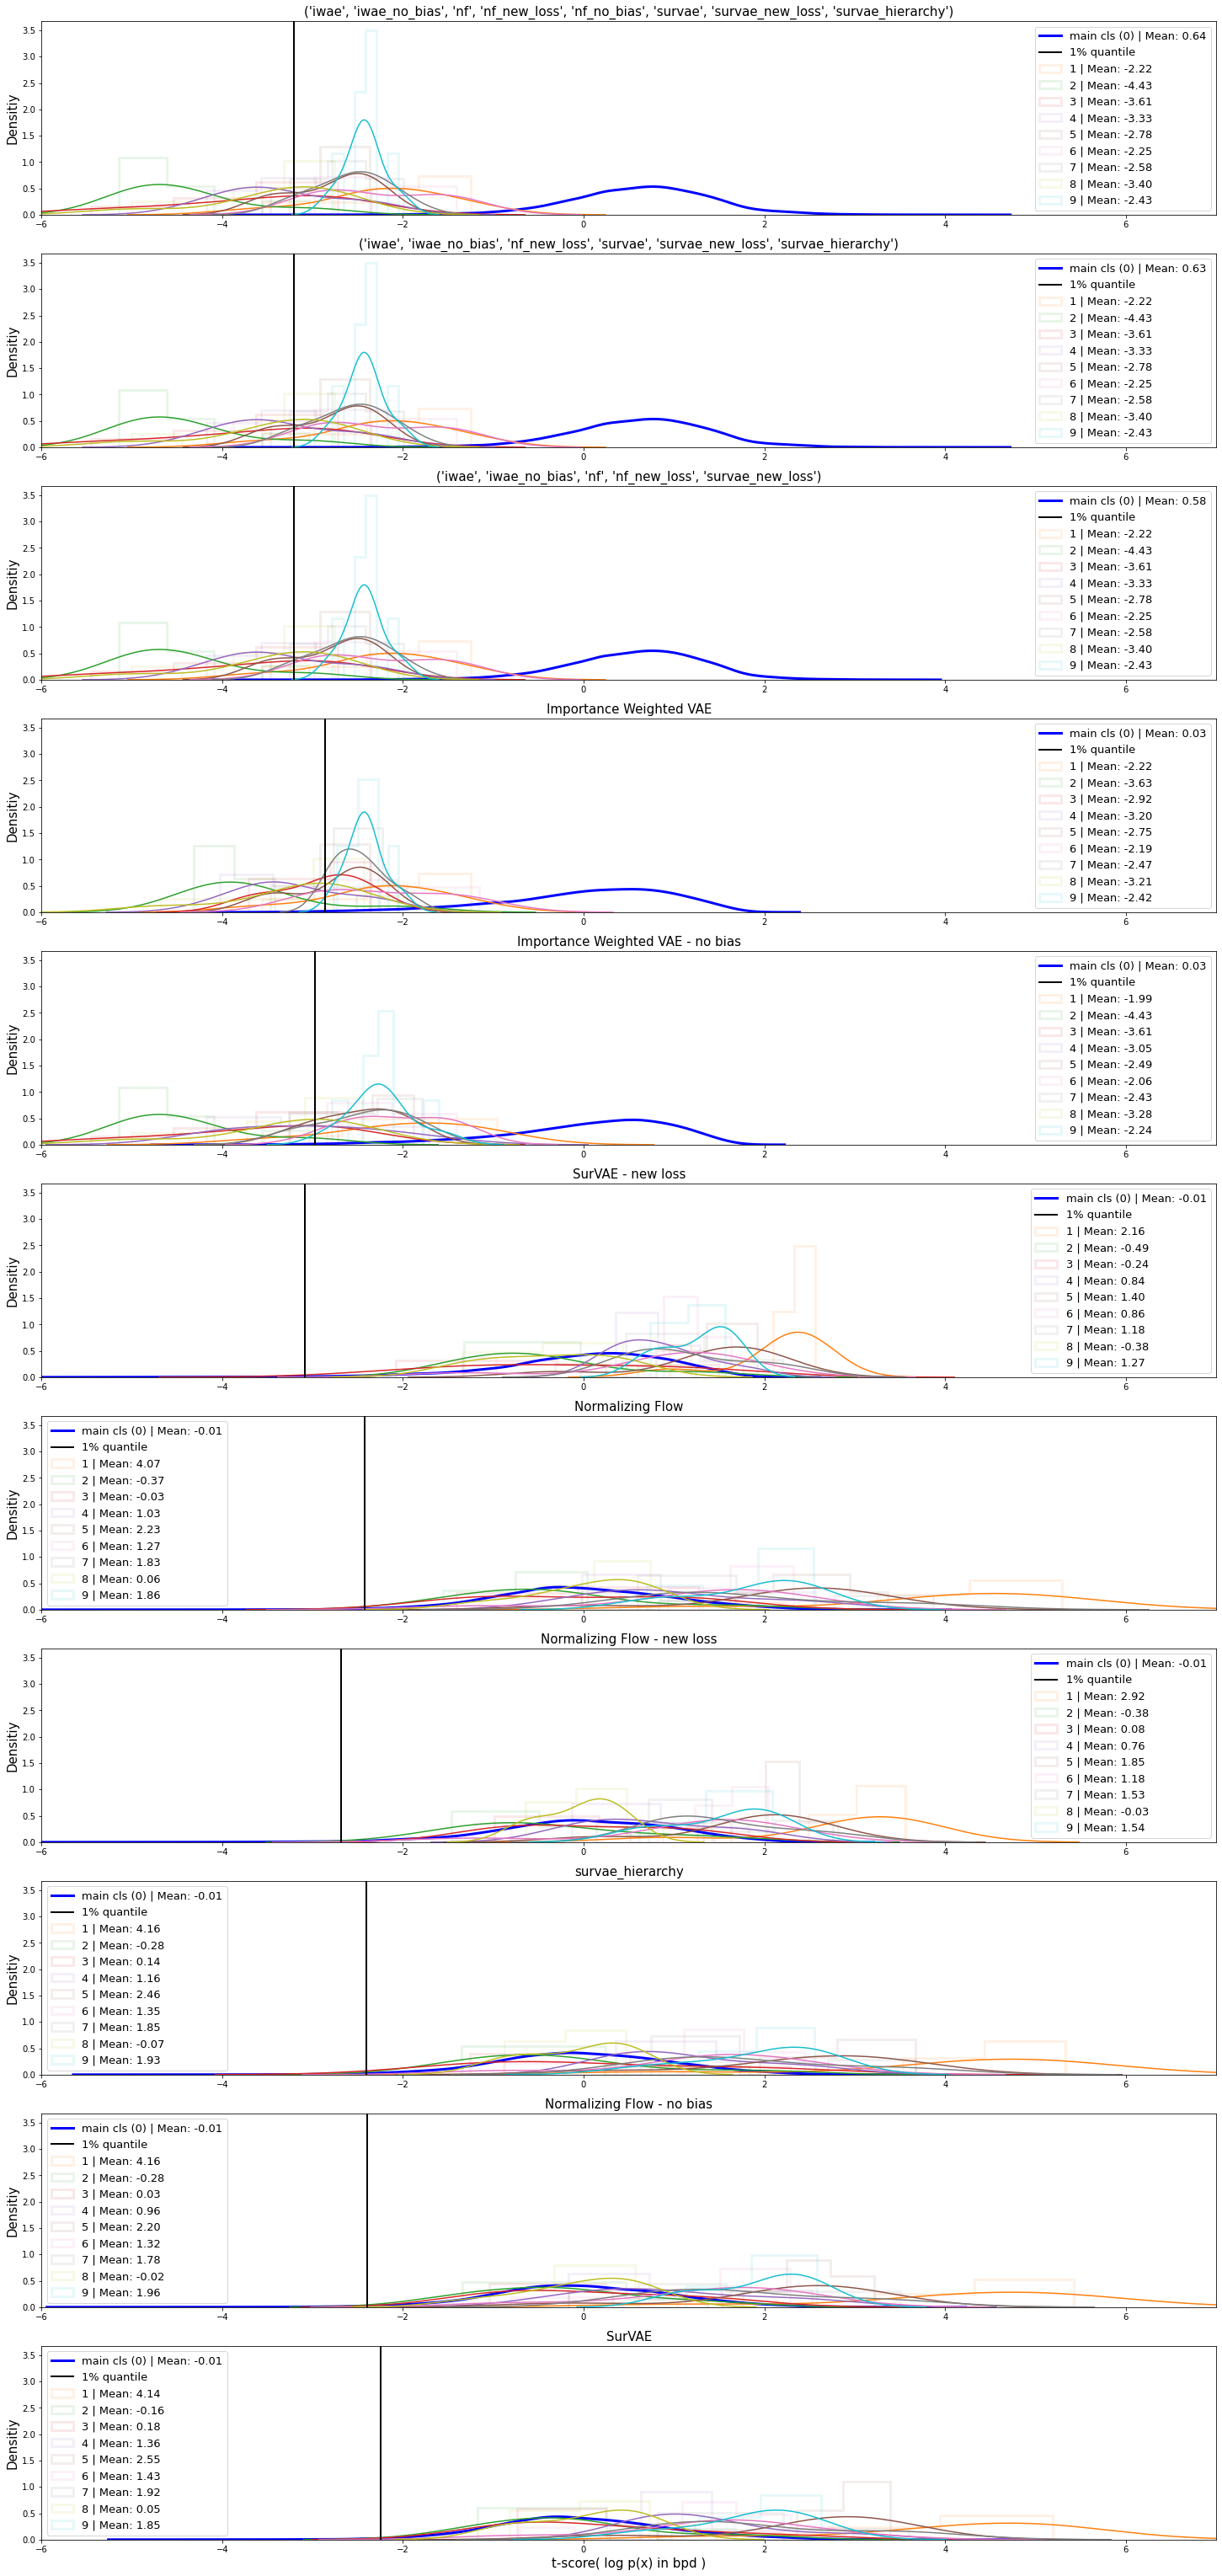

In [14]:
_=show_outlier_loss_histogram(expert_mixtures, score_idx=T_SCORE, lim_left=-6, lim_right=7)

NameError: name 'cleaned_experts' is not defined

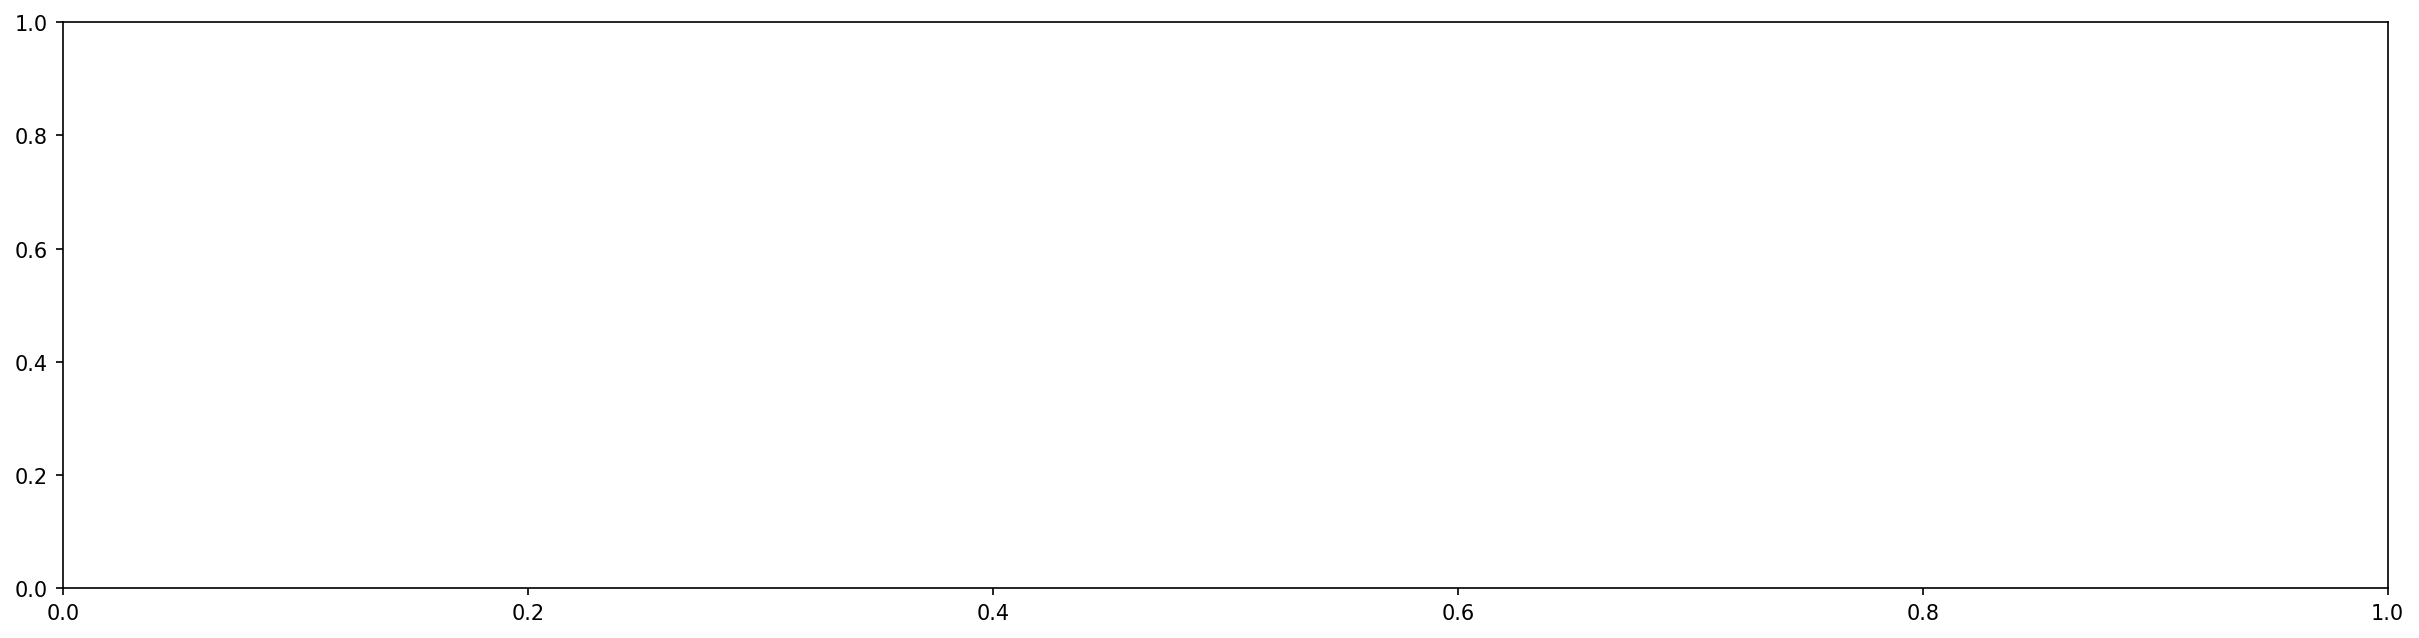

In [15]:
from matplotlib.ticker import FixedLocator, FixedFormatter

#fig = plt.figure(figsize=(10,5))
fig, ax = plt.subplots(figsize=(20, 5), dpi=150)
#ax = plt.subplot(111)

lable_pos = []
lables = []
for combo, score in cleaned_experts:
    vline(score, combo, ax=ax, color='k')
    lable_pos.append(score)
    lables.append(combo)
    
# Don't display *any* major ticks labels
ax.set_yticks([])
#ax.set_yticklabels('')
ax.set_xticks(np.arange(0, 1.05, 0.05))

#ax.xaxis.set_minor_locator(FixedLocator(lable_pos))
#ax.xaxis.set_minor_formatter(FixedFormatter(lables))
_=fig.suptitle(f'Percentage of outliers > {QUANTILE*100:.0f}% worst inliers')

#print(sorted_score)